<a href="https://colab.research.google.com/github/maizoh/Project_Shinshu/blob/main/Project_Shinshu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
pd.set_option('display.max_rows', None)
df=pd.read_csv("/content/Medical_Data/MedicalReportPubH_2024.csv",encoding="shift_jis")
df=pd.DataFrame(df)
df_selected=df.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]]
df_selected.to_pickle("/content/Medical_Data/df_selected_2024.pickle")

In [29]:
df = pd.read_pickle("/content/Medical_Data/df_selected_2024.pickle")
df.to_csv("/content/Medical_Data/df_test_2024.csv", index=False)

In [30]:
df = pd.read_pickle("/content/Medical_Data/df_selected_2024.pickle")
df_med=df[df["概要"]=="薬剤"]
df_med["当事者職種経験（年数）_1"].value_counts()

,count
当事者職種経験（年数）_1,
0年,921
1年,572
2年,409
3年,278
4年,238
5年,193
7年,161
10年,152
6年,148


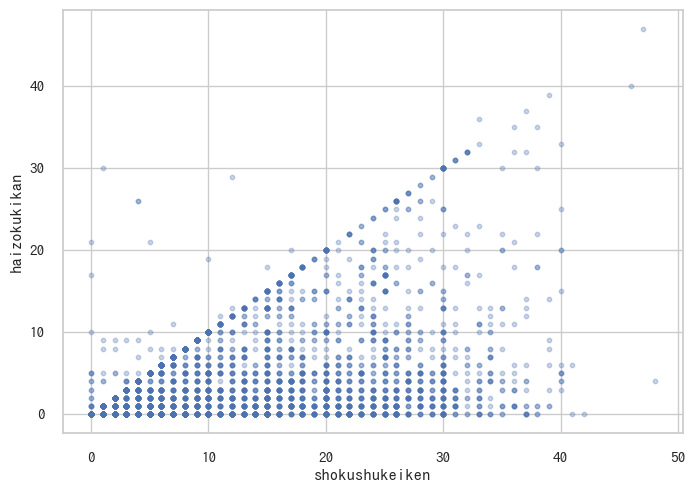

<Figure size 600x100 with 0 Axes>

In [31]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots()

plt.figure(figsize=(6,1))

ax.set_xlabel("shokushukeiken")
ax.set_ylabel("haizokukikan")

df["当事者職種経験（年数）_1"]=df["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df['当事者部署配属期間（年数）_1']=df['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)
x=df["当事者職種経験（年数）_1"]
y=df['当事者部署配属期間（年数）_1']

ax.scatter(x,y,s=10,alpha=0.3)

plt.show()

y=xは配属機関が１か所だけってことだから、多くなるのは必然？
y=x越すはずないのに越してるやつらいるので洗浄する

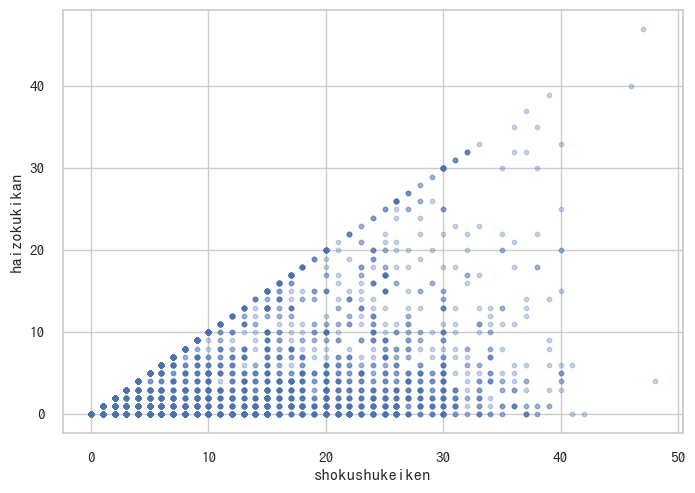

<Figure size 600x100 with 0 Axes>

In [32]:
df_clean=df[df['当事者職種経験（年数）_1']>=df['当事者部署配属期間（年数）_1']].copy()
fig,ax=plt.subplots()

plt.figure(figsize=(6,1))

ax.set_xlabel("shokushukeiken")
ax.set_ylabel("haizokukikan")

df_clean["当事者職種経験（年数）_1"]=df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1']=df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)
x=df_clean["当事者職種経験（年数）_1"]
y=df_clean['当事者部署配属期間（年数）_1']

ax.scatter(x,y,s=10,alpha=0.3)

plt.show()

20から30年あたりが顕著だが、こんだけのベテランでも配属期間が短いほどミスしやすくなっている感じがある。(下のほうが濃いことから)

In [33]:
df=df_clean

In [34]:
df.groupby("当事者職種経験（年数）_1")["概要"].value_counts()

当事者職種経験（年数）_1  概要       
0              薬剤           907
               医療機器等        119
               ドレーン・チューブ      3
               療養上の世話         2
1              薬剤           567
               医療機器等        111
               療養上の世話         3
               ドレーン・チューブ      2
2              薬剤           406
               医療機器等        101
               療養上の世話         4
               その他            2
               ドレーン・チューブ      2
3              薬剤           272
               医療機器等         65
               ドレーン・チューブ      6
               検査             2
               その他            1
               療養上の世話         1
4              薬剤           234
               医療機器等         62
               療養上の世話         3
               ドレーン・チューブ      1
               検査             1
5              薬剤           190
               医療機器等         49
               ドレーン・チューブ      5
               検査             1
               療養上の世話         1
6              薬剤           147
               医療機器等         45
               ドレーン・チューブ      1
               検査             1
               治療・処置          1
               療養上の世話         1
               輸血             1
7              薬剤           161
               医療機器等         29
               ドレーン・チューブ      2
               その他            1
               検査             1
               治療・処置          1
8              薬剤           128
               医療機器等         24
               検査             1
9              薬剤           118
               医療機器等         28
               その他            1
               検査             1
               治療・処置          1
10             薬剤           151
               医療機器等         29
               ドレーン・チューブ      2
               検査             2
               その他            1
               治療・処置          1
11             薬剤            69
               医療機器等         25
12             薬剤            75
               医療機器等         26
               治療・処置          1
13             薬剤            74
               医療機器等         27
               治療・処置          1
14             薬剤            68
               医療機器等         14
15             薬剤           138
               医療機器等         36
               ドレーン・チューブ      2
               その他            1
               検査             1
               治療・処置          1
               療養上の世話         1
16             薬剤            84
               医療機器等         24
               療養上の世話         1
17             薬剤            83
               医療機器等         22
               検査             2
18             薬剤            74
               医療機器等         17
               その他            1
               ドレーン・チューブ      1
19             薬剤            38
               医療機器等         15
               療養上の世話         1
20             薬剤           105
               医療機器等         29
               ドレーン・チューブ      2
               検査             2
               その他            1
               治療・処置          1
21             薬剤            58
               医療機器等         13
               その他            1
               療養上の世話         1
22             薬剤            63
               医療機器等         12
               ドレーン・チューブ      1
               検査             1
23             薬剤            58
               医療機器等         13
               療養上の世話         1
24             薬剤            49
               医療機器等         35
               検査             3
               その他            2
25             薬剤            74
               医療機器等         25
26             薬剤            74
               医療機器等         15
27             薬剤            47
               医療機器等         18
               治療・処置          1
28             薬剤            52
               医療機器等          6
               ドレーン・チューブ      1
29             薬剤            33
               医療機器等          4
30             薬剤            81
               医療機器等         21
               その他            1
31             薬剤            27
               医療機器等          3
       

どの年代でも薬剤ミスが多い

当事者部署配属期間（年数）_1
0     23.592493
2     11.796247
1     11.528150
10     9.651475
3      9.115282
5      6.568365
4      5.227882
13     3.619303
6      3.217158
11     3.083110
7      3.083110
8      2.949062
12     2.278820
15     2.010724
9      1.340483
14     0.938338
Name: proportion, dtype: float64


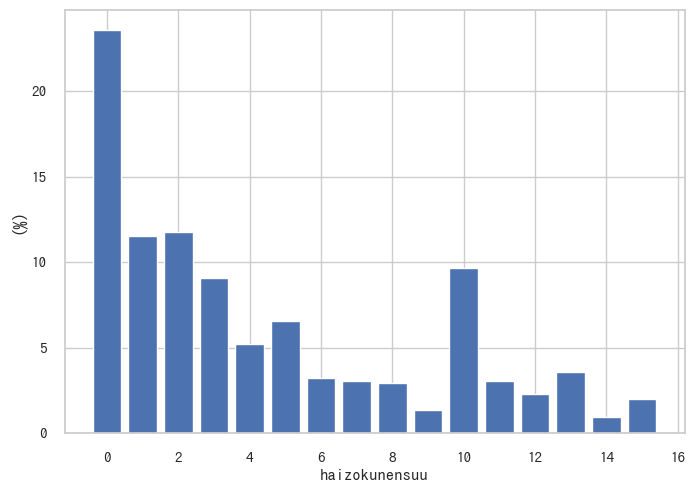

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= 10) & (df_clean["当事者職種経験（年数）_1"] <= 15)]

# 2. 比率の集計（ここで比率データを作る）
assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100

# 3. グラフ描画の設定
fig, ax = plt.subplots()

# x軸には「年数（index）」、y軸には「比率（値）」を渡す
x = assignment_ratio.index
y = assignment_ratio.values

ax.bar(x, y)


ax.set_xlabel("haizokunensuu")
ax.set_ylabel("(%)")


print(assignment_ratio)
plt.show()

In [36]:
assignment_ratio.head()

,proportion
当事者部署配属期間（年数）_1,
0,23.592493
2,11.796247
1,11.528150
10,9.651475
3,9.115282


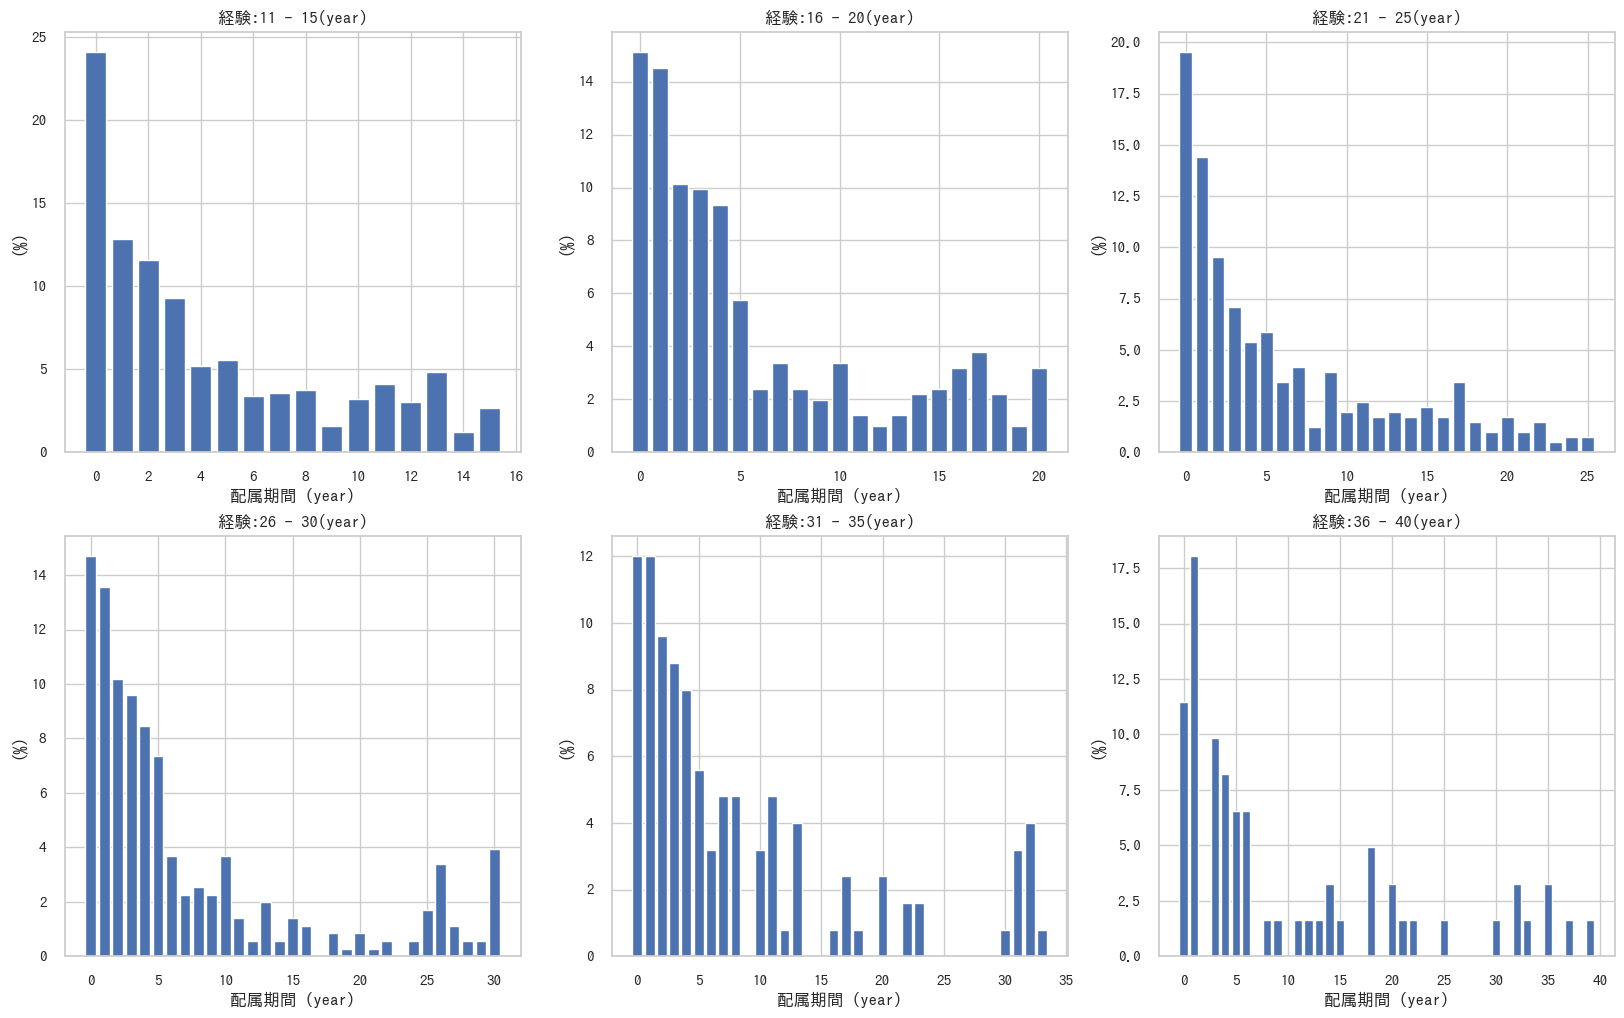

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

# 3. グラフ描画の設定
fig, ax = plt.subplots(2,3,figsize=(20,12))
#(2,3)にしたことでaxがndarrayオブジェクトになっているため、ax.barが使えない。書くべき場所が6か所あるのにどこに書くか指定してないからバグる。
ax=ax.flatten()

for i,year in enumerate(range(11,41,5)):
#enumerateはyearが取り出しているものに対してiがナンバリングしていく感じ


  filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= year) & (df_clean["当事者職種経験（年数）_1"] <= year+4)]

  # 2. 比率の集計（ここで比率データを作る）
  assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100



  # x軸には「年数（index）」、y軸には「比率（値）」を渡す
  x = assignment_ratio.index
  y = assignment_ratio.values

  ax[i].bar(x,y)


  ax[i].set_xlabel("配属期間 (year)")
  ax[i].set_ylabel("(%)")

  a=f"経験:{year} - {year+4}(year)"
  ax[i].set_title(a)

plt.show()


1.  fig, ax = plt.subplots(2,3)→[[ax00, ax01, ax02],[ax10, ax11, ax12]]という構造
2.  ax.flatten()で１次元構造に変換→[ax00, ax01, ax02, ax10, ax11, ax12]
　　アクセスがax[2]などで可能に






In [40]:
df_med["事例の内容"].value_counts()

,count
事例の内容,
無投薬,872
その他の与薬に関する内容,465
過剰投与,427
投与速度速すぎ,340
過少投与,304
投与時間・日付間違い,244
処方忘れ,242
その他の与薬準備に関する内容,225
その他の処方に関する内容,175


In [41]:
df_instant=df[df['概要']=="薬剤"]
df_medicine_com=df_instant[df['発生要因_環境・設備機器']=="コンピュータシステム"]
df_medicine_com.shape
#med_comは薬剤かつコンピューターが要因
df_medicine_com["事例の内容"].value_counts()

/tmp/ipykernel_25421/575164429.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_medicine_com=df_instant[df['発生要因_環境・設備機器']=="コンピュータシステム"]


,count
事例の内容,
無投薬,31
処方忘れ,20
その他の処方に関する内容,20
過剰投与,12
その他の与薬準備に関する内容,12
処方量間違い,11
その他の与薬に関する内容,10
薬剤間違い,9
その他の調剤に関する内容,9


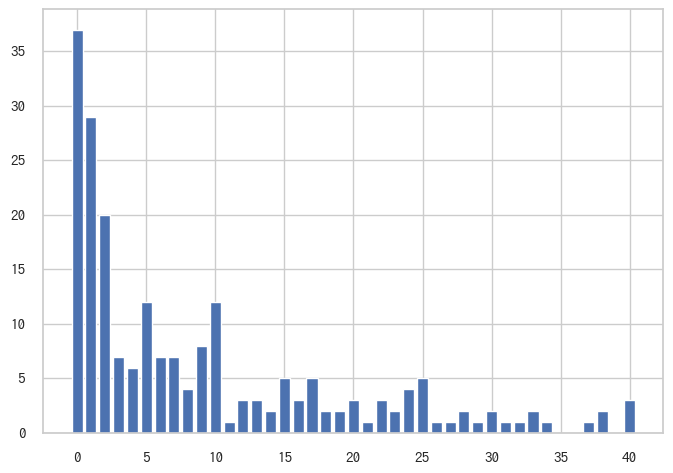

In [39]:
fig,ax=plt.subplots()

x=df_medicine_com['当事者職種経験（年数）_1'].value_counts().index
y=df_medicine_com["当事者職種経験（年数）_1"].value_counts().values

ax.bar(x,y)

plt.show()

コンピューターだからって年齢高いほどミスるわけじゃなさげ

In [42]:
df_medicine_com.shape

(211, 15)

In [43]:
df_medicine_com["発生要因_その他"].value_counts()



,count
発生要因_その他,
その他,35
教育・訓練,31
仕組み,25
ルールの不備,16
仕組み ルールの不備,5
教育・訓練 ルールの不備,4
教育・訓練 仕組み,3
教育・訓練 仕組み ルールの不備,1
教育・訓練 その他,1


In [44]:
df_medicine_com.to_csv("/content/Medical_Data/df_medicine_com.csv")

In [45]:
df.shape

(6022, 15)

In [46]:
# 1. 日本語フォントをインストール
!apt-get -y install fonts-ipafont-gothic

# 2. キャッシュを消去（これをしないと反映されないことがある）
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import shutil

# 古いキャッシュを削除
cache_dir = mpl.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. フォントとスタイルを設定
plt.style.use("seaborn-v0_8")
plt.rcParams["font.family"] = "IPAGothic"  # インストールしたフォントを指定

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipafont-gothic is already the newest version (00303-21ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


--- 新・集計結果サマリー ---
               件数      割合（%）
薬の形態                        
内服薬          1992  40.719542
点滴・輸液        1190  24.325429
処方・指示・同意書     704  14.390842
その他           569  11.631235
注射            239   4.885527
外用薬（テープ・貼付）   198   4.047424


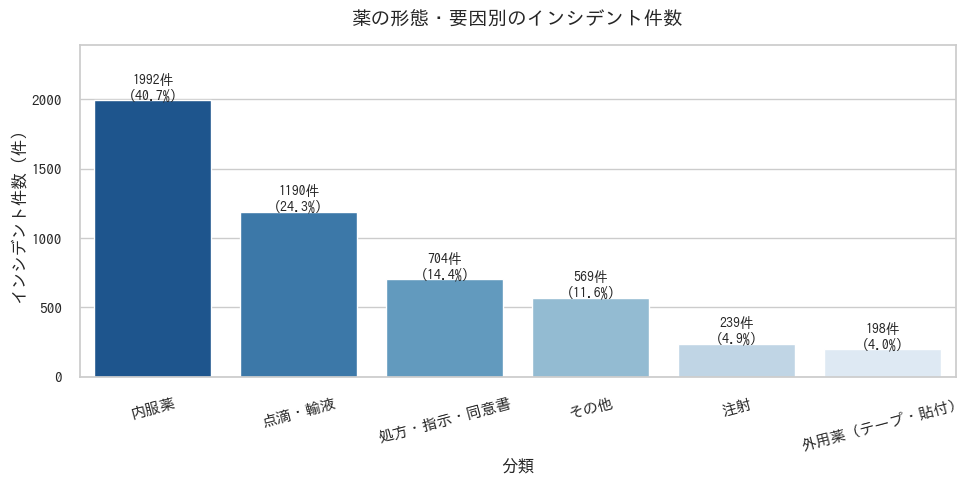

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. サンプルデータから分析した「最強のキーワード辞書」
# 上から順番に判定されるため、具体的な言葉を上に配置するのがコツだよ！
KEYWORD_MAPPING = {
    # 外用薬・貼り薬（データ内に多発）
    "テープ": "外用薬（テープ・貼付）",
    "貼付": "外用薬（テープ・貼付）",
    # 点滴・注射の表記ゆれをカバー
    "点滴": "点滴・輸液",
    "輸液": "点滴・輸液",
    "生食": "点滴・輸液",
    "注射": "注射",
    "インジェクター": "注射",
    # 内服の表記ゆれ・関連語
    "内服": "内服薬",
    "錠": "内服薬",
    "分包": "内服薬",
    "粉砕": "内服薬",
    # 薬の種類そのものではなく、プロセスや書類のミス（ここが盲点！）
    "処方箋": "処方・指示・同意書",
    "処方": "処方・指示・同意書",
    "指示": "処方・指示・同意書",
    "同意書": "処方・指示・同意書",
    "オーダー": "処方・指示・同意書",
}


def check_keywords(text):
    text = str(text)
    for key, val in KEYWORD_MAPPING.items():
        if key in text:
            return val
    return "その他"


# 2. 列「薬の形態」の作成（カラム名：事例の内容.1）
df_med["薬の形態"] = df_med["事例の内容.1"].apply(check_keywords)

# 3. 集計処理
summary_df = pd.DataFrame(
    {
        "件数": df_med["薬の形態"].value_counts(),
        "割合（%）": df_med["薬の形態"].value_counts(normalize=True) * 100,
    }
)

print("--- 新・集計結果サマリー ---")
print(summary_df)

# 4. グラフの描画
plt.figure(figsize=(10, 5))  # 横幅を少し広げて文字被りを防ぐ
sns.set_theme(style="whitegrid", font="IPAGothic")

ax = sns.barplot(
    x=summary_df.index,
    y=summary_df["件数"],
    palette="Blues_r",
    hue=summary_df.index,
    legend=False,
)

plt.title("薬の形態・要因別のインシデント件数", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("分類", fontsize=12)
plt.ylabel("インシデント件数（件）", fontsize=12)
plt.xticks(rotation=15)  # 文字が長くなったので少し斜めにして見やすく

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / len(df_med)) * 100
        ax.annotate(
            f"{int(height)}件\n({percentage:.1f}%)",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 10),
            textcoords="offset points",
            fontsize=10,
        )

plt.ylim(0, summary_df["件数"].max() * 1.2)
plt.tight_layout()
plt.show()